In [18]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
small_molecules = {
    "Methanol": "CO",
    "Ethanol": "CCO",
    "Acetone": "CC(=O)C",
    "Acetic Acid": "CC(=O)O",
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Glucose": "C(C1C(C(C(C(O1)O)O)O)O)O",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Benzene": "c1ccccc1",
    "Toluene": "CC1=CC=CC=C1"
}

In [14]:
def characterize_molecules(smiles_list):
    results = []

    for name, smi in smiles_list.items():
        mol = Chem.MolFromSmiles(smi)
        if mol:
            # Number of atoms
            num_atoms = mol.GetNumAtoms()

            # Number of rotatable bonds
            num_rotatable_bonds = Descriptors.NumRotatableBonds(mol)

            # Molecular weight
            mol_weight = Descriptors.MolWt(mol)

            # Type of elements
            elements = {atom.GetSymbol() for atom in mol.GetAtoms()}
            elements = sorted(elements)
            # Append results as a dictionary
            results.append({
                "name":name,
                "Number of atoms": num_atoms,
                "Number of rotatable bonds": num_rotatable_bonds,
                "Molecular weight": mol_weight,
                "Elements": ', '.join(sorted(elements))  # Convert set to a sorted, comma-separated string
            })
        else:
            print(f"SMILES '{smi}' could not be parsed.")
    print(results)
    # Convert results to DataFrame
    df = pd.DataFrame(results)
    return df

In [20]:
df=characterize_molecules(small_molecules)

[{'name': 'Methanol', 'Number of atoms': 2, 'Number of rotatable bonds': 0, 'Molecular weight': 32.042, 'Elements': 'C, O'}, {'name': 'Ethanol', 'Number of atoms': 3, 'Number of rotatable bonds': 0, 'Molecular weight': 46.069, 'Elements': 'C, O'}, {'name': 'Acetone', 'Number of atoms': 4, 'Number of rotatable bonds': 0, 'Molecular weight': 58.08, 'Elements': 'C, O'}, {'name': 'Acetic Acid', 'Number of atoms': 4, 'Number of rotatable bonds': 0, 'Molecular weight': 60.05200000000001, 'Elements': 'C, O'}, {'name': 'Aspirin', 'Number of atoms': 13, 'Number of rotatable bonds': 2, 'Molecular weight': 180.15899999999996, 'Elements': 'C, O'}, {'name': 'Glucose', 'Number of atoms': 12, 'Number of rotatable bonds': 1, 'Molecular weight': 180.156, 'Elements': 'C, O'}, {'name': 'Caffeine', 'Number of atoms': 14, 'Number of rotatable bonds': 0, 'Molecular weight': 194.194, 'Elements': 'C, N, O'}, {'name': 'Benzene', 'Number of atoms': 6, 'Number of rotatable bonds': 0, 'Molecular weight': 78.11399

In [23]:
len(df['Molecular weight'])

9

Text(0.5, 1.0, 'Histogram of Molecular Weights')

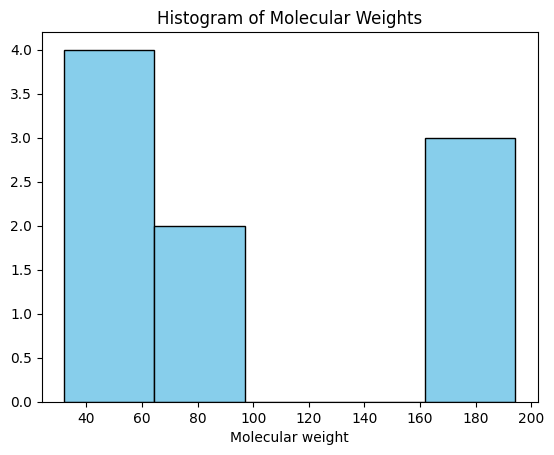

In [21]:

plt.hist(df['Molecular weight'], bins=5, color='skyblue', edgecolor='black')
plt.xlabel('Molecular weight')
plt.title('Histogram of Molecular Weights')

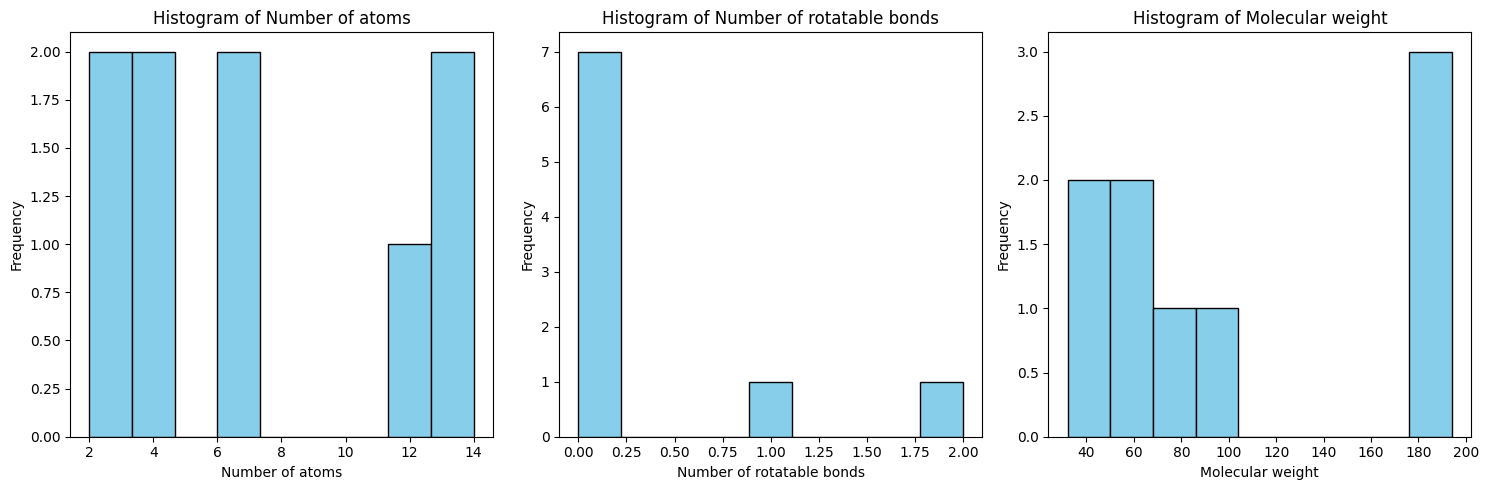

In [25]:
# Plotting multiple histograms
columns_to_plot = ["Number of atoms", "Number of rotatable bonds", "Molecular weight"]
fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 5))

for i, column in enumerate(columns_to_plot):
    axes[i].hist(df[column], bins=9, color='skyblue', edgecolor='black')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Histogram of {column}')

plt.tight_layout()
plt.show()